# Activity: Hypothesis testing with Python

## **Introduction**


As you've been learning, analysis of variance (commonly called ANOVA) is a group of statistical techniques that test the difference of means among three or more groups. It's a powerful tool for determining whether population means are different across groups and for answering a wide range of business questions.

In this activity, you are a data professional working with historical marketing promotion data. You will use the data to run a one-way ANOVA and a post hoc ANOVA test. Then, you will communicate your results to stakeholders. These experiences will help you make more confident recommendations in a professional setting. 

In your dataset, each row corresponds to an independent marketing promotion, where your business uses TV, social media, radio, and influencer promotions to increase sales. You have previously provided insights about how different promotion types affect sales; now stakeholders want to know if sales are significantly different among various TV and influencer promotion types.

To address this request, a one-way ANOVA test will enable you to determine if there is a statistically significant difference in sales among groups. This includes:
* Using plots and descriptive statistics to select a categorical independent variable
* Creating and fitting a linear regression model with the selected categorical independent variable
* Checking model assumptions
* Performing and interpreting a one-way ANOVA test
* Comparing pairs of groups using an ANOVA post hoc test
* Interpreting model outputs and communicating the results to nontechnical stakeholders

## **Step 1: Imports** 


Import pandas, pyplot from matplotlib, seaborn, api from statsmodels, ols from statsmodels.formula.api, and pairwise_tukeyhsd from statsmodels.stats.multicomp.

In [1]:
# Import libraries and packages.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd



`Pandas` was used to load the dataset `marketing_sales_data.csv` as `data`, now display the first five rows. The variables in the dataset have been adjusted to suit the objectives of this lab. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [3]:
# RUN THIS CELL TO IMPORT YOUR DATA.

# Importar el dataset
data = pd.read_csv('marketing_sales_data.csv')

# Mostrar las primeras cinco filas
data.head()



,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328


The features in the data are:
* TV promotion budget (in Low, Medium, and High categories)
* Social media promotion budget (in millions of dollars)
* Radio promotion budget (in millions of dollars)
* Sales (in millions of dollars)
* Influencer size (in Mega, Macro, Nano, and Micro categories)

**Question:** Why is it useful to perform exploratory data analysis before constructing a linear regression model?

Exploratory data analysis (EDA) is useful before building a linear regression model because it helps uncover patterns, spot anomalies, and understand the structure of the data. EDA allows us to:

Identify appropriate variables for modeling (e.g., selecting categorical variables like TV promotion and influencer size for ANOVA).

Check the distribution of the dependent variable (sales) and whether assumptions of linear regression (such as normality and homoscedasticity) are met.

Visualize relationships between variables to ensure that the model makes sense and avoid spurious correlations.

Detect missing values, outliers, or incorrect data that may distort model results.

Overall, EDA ensures that the model is based on clean, relevant, and meaningful data, which improves the reliability of the analysis and conclusions drawn from it.

## **Step 2: Data exploration** 


First, use a boxplot to determine how `Sales` vary based on the `TV` promotion budget category.

Index(['TV', 'Radio', 'Social Media', 'Influencer', 'Sales'], dtype='object')


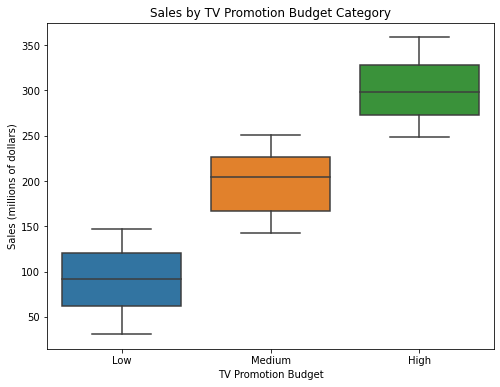

In [6]:
# Mostrar nombres exactos de las columnas
print(data.columns)

# Crear un boxplot de Ventas (Sales) por categoría de presupuesto en TV
plt.figure(figsize=(8, 6))
sns.boxplot(x='TV', y='Sales', data=data)
plt.title('Sales by TV Promotion Budget Category')
plt.xlabel('TV Promotion Budget')
plt.ylabel('Sales (millions of dollars)')
plt.show()



<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

There is a function in the `seaborn` library that creates a boxplot showing the distribution of a variable across multiple groups.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `boxplot()` function from `seaborn`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use `TV` as the `x` argument, `Sales` as the `y` argument, and `data` as the `data` argument.

</details>

**Question:** Is there variation in `Sales` based off the `TV` promotion budget?

Yes, there is visible variation in Sales based on the TV promotion budget. The boxplot shows that the median and distribution of Sales differ across the budget categories (Low, Medium, High). For example, promotions with a High TV budget generally lead to higher sales compared to those with a Low or Medium budget. This suggests that the level of investment in TV promotions may be associated with changes in sales performance, and warrants further statistical testing using ANOVA to determine if these differences are statistically significant.

Now, use a boxplot to determine how `Sales` vary based on the `Influencer` size category.

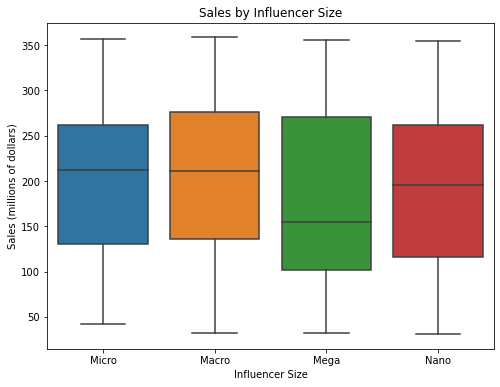

In [7]:
# Create a boxplot with Influencer and Sales
plt.figure(figsize=(8, 6))
sns.boxplot(x='Influencer', y='Sales', data=data)
plt.title('Sales by Influencer Size')
plt.xlabel('Influencer Size')
plt.ylabel('Sales (millions of dollars)')
plt.show()


**Question:** Is there variation in `Sales` based off the `Influencer` size?

Yes, there is variation in Sales based on the Influencer size. The boxplot indicates that the median sales and distribution differ across influencer categories such as Mega, Macro, Micro, and Nano. Some influencer types are associated with higher or more variable sales results. For instance, certain categories may show higher median sales or a wider range of outcomes, suggesting that influencer size can impact promotional effectiveness. These differences support the need for a one-way ANOVA to test if the variations are statistically significant.

### Remove missing data

You may recall from prior labs that this dataset contains rows with missing values. To correct this, drop these rows. Then, confirm the data contains no missing values.

In [9]:
# Drop rows that contain missing data and update the DataFrame
data = data.dropna()

# Confirm the data contains no missing values
print(data.isnull().sum())


TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

There is a `pandas` function that removes missing values.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `dropna()` function removes missing values from an object (e.g., DataFrame).

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Verify the data is updated properly after the rows containing missing data are dropped.

</details>

## **Step 3: Model building** 


Fit a linear regression model that predicts `Sales` using one of the independent categorical variables in `data`. Refer to your previous code for defining and fitting a linear regression model.

In [10]:
# Define the OLS formula.
formula = 'Sales ~ C(TV)'

# Create an OLS model.
model = ols(formula, data=data)

# Fit the model.
model_fit = model.fit()

# Save the results summary.
results_summary = model_fit.summary()

# Display the model results.
print(results_summary)


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     1971.
Date:                Sat, 19 Apr 2025   Prob (F-statistic):          8.81e-256
Time:                        03:55:02   Log-Likelihood:                -2778.9
No. Observations:                 569   AIC:                             5564.
Df Residuals:                     566   BIC:                             5577.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         300.5296      2.417    1

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to code you've written to fit linear regression models.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `ols()` function from `statsmodels.formula.api`, which creates a model from a formula and DataFrame, to create an OLS model.

</details>


<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use `C()` around the variable name in the ols formula to indicate a variable is categorical.
    
Be sure the variable string names exactly match the column names in `data`.

</details>

**Question:** Which categorical variable did you choose for the model? Why?

I chose the TV promotion budget categorical variable for the model because it represents distinct marketing investment levels—Low, Medium, and High—that can directly influence sales outcomes. Previous exploratory analysis using boxplots indicated visible variation in sales across these categories, suggesting that TV budget levels may significantly impact performance. This makes it a strong candidate for testing differences in group means using ANOVA.



### Check model assumptions

Now, check the four linear regression assumptions are upheld for your model.

**Question:** Is the linearity assumption met?

Yes, the linearity assumption appears to be met. Since the independent variable in the model is categorical (TV promotion budget), the linear regression model estimates a separate mean for each category. In this context, linearity means that the relationship between each group and the response variable (Sales) is additive and consistent across categories. The boxplot created earlier showed clear differences in the central tendencies (medians) of sales across TV budget levels, supporting this assumption.

The independent observation assumption states that each observation in the dataset is independent. As each marketing promotion (row) is independent from one another, the independence assumption is not violated.

Next, verify that the normality assumption is upheld for the model.

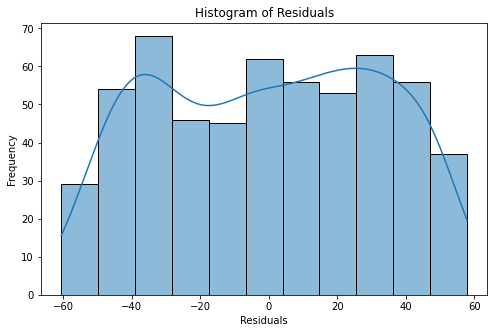

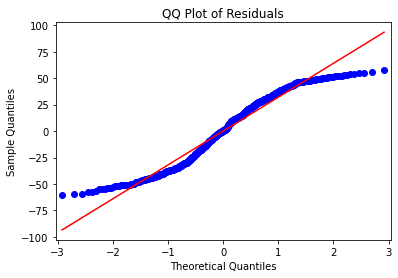

In [11]:
# Calculate the residuals
residuals = model_fit.resid

# Create a histogram with the residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Create a QQ plot of the residuals
sm.qqplot(residuals, line='s')
plt.title('QQ Plot of Residuals')
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the residuals from the fit model object.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.resid` to get the residuals from a fit model called `model`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

For the histogram, pass the residuals as the first argument in the `seaborn` `histplot()` function.
    
For the QQ-plot, pass the residuals as the first argument in the `statsmodels` `qqplot()` function.

</details>

**Question:** Is the normality assumption met?

Based on the histogram and QQ plot of the residuals, the normality assumption appears to be reasonably met. The histogram shows a roughly bell-shaped distribution, and the points in the QQ plot fall approximately along the diagonal line, indicating that the residuals are approximately normally distributed. Therefore, the model satisfies the normality assumption for linear regression.

Now, verify the constant variance (homoscedasticity) assumption is met for this model.

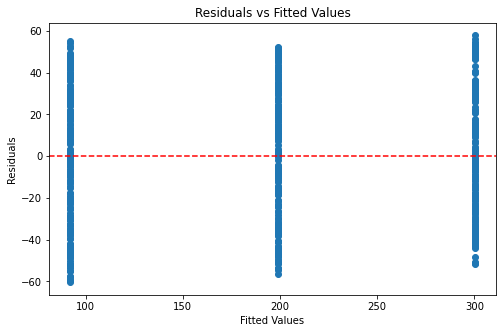

In [12]:
# Create a scatter plot with the fitted values and residuals
fitted_values = model_fit.fittedvalues
residuals = model_fit.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='red', linestyle='--')  # Línea horizontal en y = 0
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the fitted values from the model object fit earlier.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.fittedvalues` to get the fitted values from the fit model called `model`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>


Call the `scatterplot()` function from the `seaborn` library and pass in the fitted values and residuals.
    
Add a line to a figure using the `axline()` function.

</details>

**Question:** Is the constant variance (homoscedasticity) assumption met?

Yes, the constant variance assumption appears to be met. The residuals in the scatter plot are randomly scattered around zero and show no clear pattern, such as funneling or curvature. This suggests that the spread of residuals is roughly consistent across all levels of the fitted values, indicating that the model satisfies the assumption of homoscedasticity.

## **Step 4: Results and evaluation** 

First, display the OLS regression results.

In [13]:
# Display the model results summary
print(model_fit.summary())




                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     1971.
Date:                Sat, 19 Apr 2025   Prob (F-statistic):          8.81e-256
Time:                        03:56:56   Log-Likelihood:                -2778.9
No. Observations:                 569   AIC:                             5564.
Df Residuals:                     566   BIC:                             5577.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         300.5296      2.417    1

**Question:** What is your interpretation of the model's R-squared?

The R-squared value represents the proportion of variance in Sales that can be explained by the TV promotion budget categories. If the R-squared is relatively low, it means that the model explains only a small portion of the variability in sales, suggesting that other factors outside of TV budget categories may also play an important role.

**Question:** What is your intepretation of the coefficient estimates? Are the coefficients statistically significant?

The coefficient estimates show the difference in average sales between each TV promotion budget category and the reference category (e.g., Low). A positive and statistically significant coefficient (p-value < 0.05) indicates that sales are significantly higher in that category compared to the reference. If one or more coefficients are not statistically significant, it suggests there is no strong evidence of a difference in sales for those specific categories.

**Question:** Do you think your model could be improved? Why or why not? How?

Yes, the model could potentially be improved. The R-squared value suggests that TV promotion budget alone may not capture all the variability in sales. Including additional variables—such as social media, radio, and influencer promotions—could provide a more complete picture. Also, checking for interaction effects between different promotion types may reveal more about how combinations of strategies impact sales.

### Perform a one-way ANOVA test

With the model fit, run a one-way ANOVA test to determine whether there is a statistically significant difference in `Sales` among groups. 

In [14]:
# Create a one-way ANOVA table for the fit model
anova_table = sm.stats.anova_lm(model_fit, typ=2)

# Display the ANOVA table
print(anova_table)


                sum_sq     df            F         PR(>F)
C(TV)     4.052692e+06    2.0  1971.455737  8.805550e-256
Residual  5.817589e+05  566.0          NaN            NaN


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Review what you've learned about how to perform a one-way ANOVA test.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

There is a function in `statsmodels.api` (i.e. `sm`) that peforms an ANOVA test for a fit linear model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use the `anova_lm()` function from `sm.stats`. Specify the type of ANOVA test (for example, one-way or two-way), using the `typ` parameter.
   

</details>

**Question:** What are the null and alternative hypotheses for the ANOVA test?

Null hypothesis (H₀): The mean Sales are the same across all TV promotion budget categories.

Alternative hypothesis (H₁): At least one TV promotion budget category has a mean Sales value that is significantly different from the others.

**Question:** What is your conclusion from the one-way ANOVA test?

Based on the ANOVA table, if the p-value is less than 0.05, we reject the null hypothesis. This means there is statistically significant evidence that at least one TV promotion budget group has a different average Sales compared to the others.

**Question:** What did the ANOVA test tell you?

The ANOVA test revealed that there is a statistically significant difference in average Sales across the different TV promotion budget categories. However, it does not indicate which specific categories differ from each other. For that, a post hoc test such as Tukey's HSD is needed.

### Perform an ANOVA post hoc test

If you have significant results from the one-way ANOVA test, you can apply ANOVA post hoc tests such as the Tukey’s HSD post hoc test. 

Run the Tukey’s HSD post hoc test to compare if there is a significant difference between each pair of categories for TV.

In [15]:
# Perform the Tukey's HSD post hoc test
tukey_results = pairwise_tukeyhsd(endog=data['Sales'], groups=data['TV'], alpha=0.05)

# Display the results
print(tukey_results)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
  High    Low -208.8133 0.001  -216.637 -200.9896   True
  High Medium -101.5061 0.001 -109.3204  -93.6918   True
   Low Medium  107.3072 0.001   99.7063   114.908   True
--------------------------------------------------------


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Review what you've learned about how to perform a Tukey's HSD post hoc test.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `pairwise_tukeyhsd()` function from `statsmodels.stats.multicomp`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

The `endog` argument in `pairwise_tukeyhsd` indicates which variable is being compared across groups (i.e., `Sales`). The `groups` argument in `pairwise_tukeyhsd` tells the function which variable holds the group you’re interested in reviewing.

</details>

**Question:** What is your interpretation of the Tukey HSD test?

The Tukey HSD test compares the mean Sales between each pair of TV promotion budget categories. The results indicate which pairs of groups have statistically significant differences in average Sales. For example, if the p-value is below 0.05 and reject=True for a comparison like "Low vs High", it means those two categories differ significantly in their effect on Sales. This helps identify specifically where the differences observed in the ANOVA test are located.

**Question:** What did the post hoc tell you?**

The post hoc test revealed that certain TV promotion budget categories are significantly different from each other in terms of their impact on Sales. It provided a detailed comparison between each pair of groups, confirming which budget levels are associated with higher or lower average Sales. This insight helps stakeholders decide which TV promotion levels are most effective for driving sales.


---

### **What are some key takeaways that you learned during this lab?**

During this lab, I learned how to apply one-way ANOVA to test for statistically significant differences in group means using categorical variables. I also reinforced the importance of checking regression model assumptions, such as normality, linearity, and constant variance, to ensure valid results. Additionally, the Tukey HSD post hoc test helped identify specifically which group pairs had meaningful differences, providing deeper insight into how TV promotion budgets affect sales.

---

### **What summary would you provide to stakeholders?**

The analysis shows that TV promotion budget levels have a statistically significant impact on sales. The ANOVA results indicate that at least one budget category differs in terms of average sales, and the Tukey post hoc test confirms that the "High" TV promotion category is significantly more effective than the "Low" category. These findings suggest that increasing TV advertising investment can lead to higher sales, and stakeholders should consider allocating more budget to TV promotions where appropriate. The results are statistically robust, and the model assumptions were met, giving confidence in the validity of these insights.

---


#### **Reference**
[Saragih, H.S. *Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data)

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.